In [14]:
nifti_files = []

for scan_dir in scan_dirs:
    scan_name = scan_dir.name
    dicom_dir = None
    for root, dirs, files in os.walk(scan_dir):
        if any(f.lower().endswith('.dcm') for f in files):
            dicom_dir = Path(root)
            break
    
    if dicom_dir:
        print(f"Converting {scan_name}:")
        try:
            dicom2nifti.convert_directory(str(dicom_dir), str(output_dir), compression=True, reorient=True)
            generated_files = sorted(output_dir.glob("*.nii.gz"), key=os.path.getmtime, reverse=True)
            if generated_files:
                new_nifti = generated_files[0]

                clean_name = scan_name.replace(" ", "_").replace("-", "_").replace(".", "") + ".nii.gz"
                final_path = output_dir / clean_name
                if new_nifti.exists() and not final_path.exists(): 
                     new_nifti.rename(final_path)
                elif final_path.exists():
                     pass 
                else:
                     final_path = new_nifti 
                
                nifti_files.append(final_path)
                print(f"Created {final_path.name}")
        except Exception as e:
            print(f"Error converting {scan_name}: {e}")
    else:
        print(f"No DICOMs found for {scan_name}")

print(f"\nTotal NIfTI files: {len(nifti_files)}")

Converting Axial_MB_rsfMRI__EYES_OPEN___MSV22_:


c:\Users\user\Desktop\MRI_eval\.venv\Lib\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '2.16.124.113543.6006.99.0804605326103761174'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)


Created Axial_MB_rsfMRI__EYES_OPEN___MSV22_.nii.gz
Converting WIP_SOURCE_-_Axial_3D_pCASL_2000__Eyes_Open___MSV22_:
Created WIP_SOURCE___Axial_3D_pCASL_2000__Eyes_Open___MSV22_.nii.gz
Converting WIP_SOURCE_-_Axial_3D_pCASL_2500__Eyes_Open___MSV22_:
Created WIP_SOURCE___Axial_3D_pCASL_2500__Eyes_Open___MSV22_.nii.gz

Total NIfTI files: 3



Axial_MB_rsfMRI__EYES_OPEN___MSV22_.nii.gz:
BOLD map for Axial_MB_rsfMRI__EYES_OPEN___MSV22_.nii.gz:


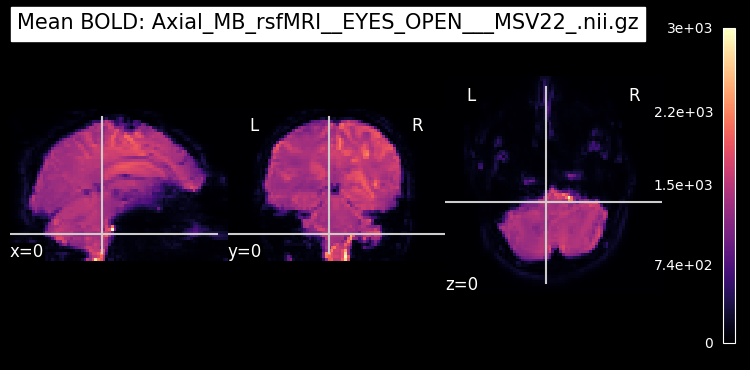

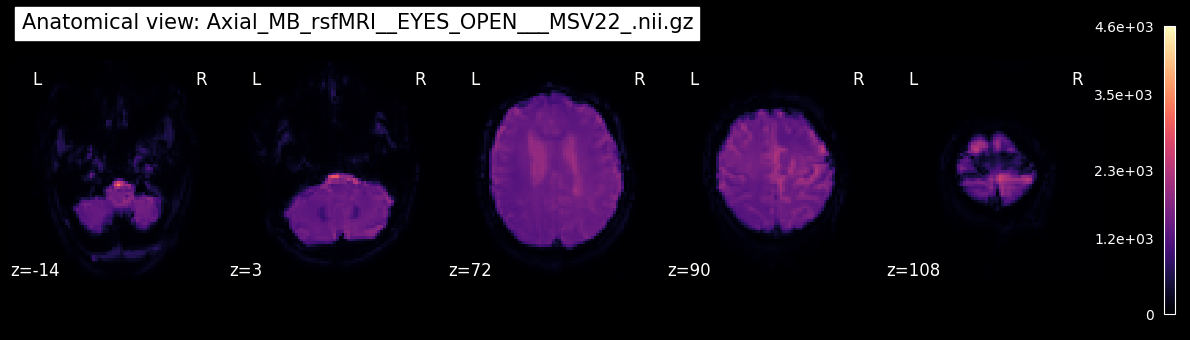

In [9]:
preprocessed_imgs = []

for nifti_path in nifti_files:
    if "rsfMRI" in nifti_path.name: 
        print(f"\n{nifti_path.name}:")
        
        img = nib.load(str(nifti_path))
   
        mean_img = image.mean_img(img)
        
        smooth_img = image.smooth_img(img, fwhm=6)
        mean_smooth_img = image.mean_img(smooth_img)
        
        mean_path = output_dir / (nifti_path.stem.split('.')[0] + "_mean.nii.gz")
        mean_img.to_filename(mean_path)
        
        print(f"BOLD map for {nifti_path.name}:")
        nlp.plot_epi(mean_img, title=f"Mean BOLD: {nifti_path.name}", display_mode='ortho', cut_coords=(0,0,0), cmap='magma')
        plt.show()
        
        nlp.plot_anat(mean_img, title=f"Anatomical view: {nifti_path.name}", display_mode='z', cut_coords=5, cmap='magma')
        plt.show()
        
        preprocessed_imgs.append(mean_path)

In [11]:
import numpy as np
import nibabel as nib
import nilearn.plotting as nlp
from nilearn import image, masking
import matplotlib.pyplot as plt


2 ASL files: ['WIP_SOURCE___Axial_3D_pCASL_2000__Eyes_Open___MSV22_.nii.gz', 'WIP_SOURCE___Axial_3D_pCASL_2500__Eyes_Open___MSV22_.nii.gz']

ASL: WIP_SOURCE___Axial_3D_pCASL_2000__Eyes_Open___MSV22_.nii.gz


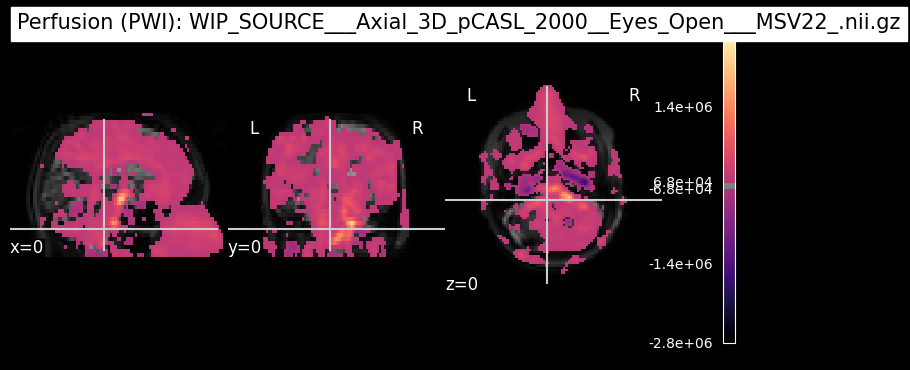

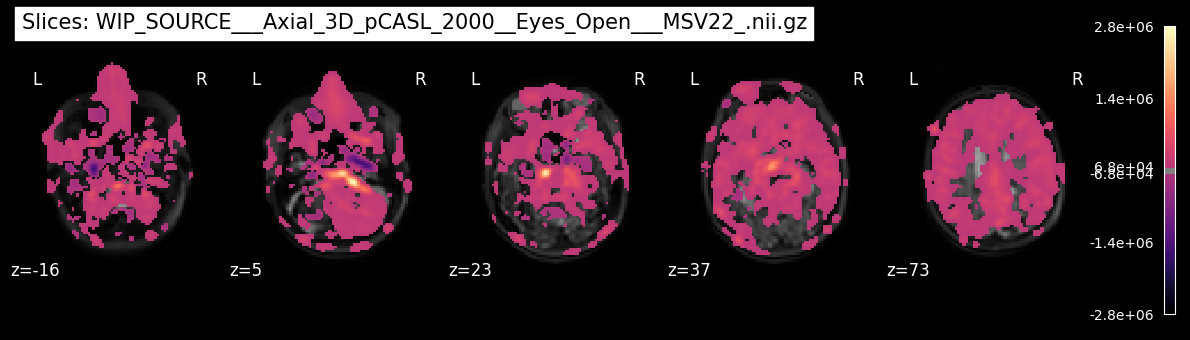


ASL: WIP_SOURCE___Axial_3D_pCASL_2500__Eyes_Open___MSV22_.nii.gz


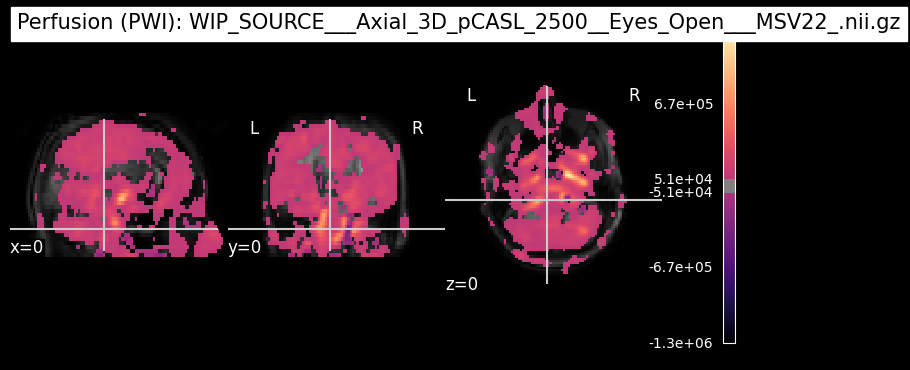

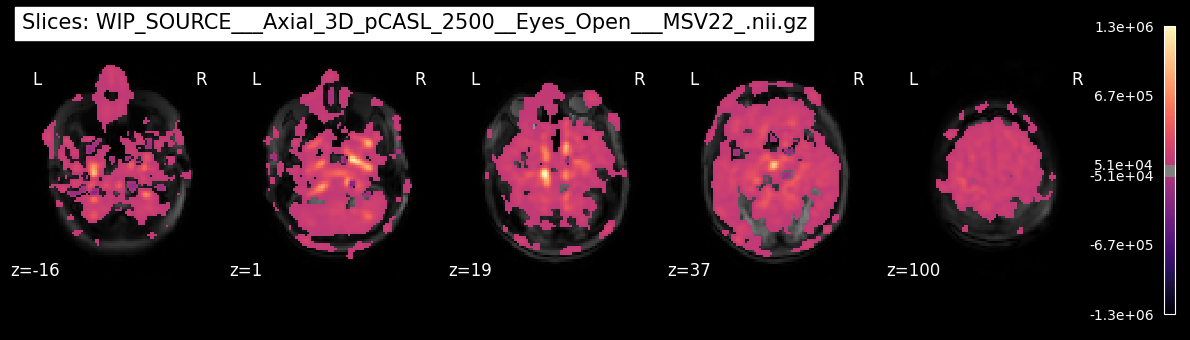

In [13]:
asl_files = [f for f in nifti_files if "pCASL" in f.name] 

print(f"{len(asl_files)} ASL files: {[f.name for f in asl_files]}")

for asl_path in asl_files: 
    print(f"\nASL: {asl_path.name}") 
    img = nib.load(str(asl_path)) 
    data = img.get_fdata()
    
    if data.ndim != 4:  #not 4D
        continue

    if data.shape[3] % 2 != 0:
        data = data[..., :-1]

    pwi_raw = np.mean(data[..., 0::2] - data[..., 1::2], axis=3)

    mask_img = masking.compute_epi_mask(image.mean_img(img))
    if np.mean(pwi_raw[mask_img.get_fdata().astype(bool)]) < 0:
        pwi_raw = -pwi_raw

    pwi_img = nib.Nifti1Image(pwi_raw, img.affine, img.header)
    pwi_smooth = image.smooth_img(pwi_img, fwhm=6)
    
    output_path = output_dir / (asl_path.stem.split('.')[0] + "_PWI_smooth.nii.gz")
    pwi_smooth.to_filename(output_path)

    mean_bg = image.mean_img(img)
    nlp.plot_stat_map(pwi_smooth, bg_img=mean_bg, title=f"Perfusion (PWI): {asl_path.name}", display_mode='ortho', cut_coords=(0,0,0), cmap='magma', threshold='auto')
    plt.show()

    nlp.plot_stat_map(pwi_smooth, bg_img=mean_bg, title=f"Slices: {asl_path.name}", display_mode='z', cut_coords=5, cmap='magma', threshold='auto')
    plt.show()

Processing: 1102_wip_source_-_axial_3d_pcasl_2000_eyes_open_msv22.nii.gz
Number of scans: 2, TR: 1.00s


C:\Users\user\AppData\Local\Temp\ipykernel_13096\383245130.py:50: UserWarning: If design matrices are supplied, [hrf_model, t_r] will be ignored.
  fmri_glm = fmri_glm.fit(img, design_matrices=design_matrix)
c:\Users\user\Desktop\MRI_eval\.venv\Lib\site-packages\nilearn\glm\regression.py:196: RuntimeWarning: divide by zero encountered in divide
  dispersion = np.sum(wresid**2, 0) / (
c:\Users\user\Desktop\MRI_eval\.venv\Lib\site-packages\nilearn\glm\regression.py:196: RuntimeWarning: invalid value encountered in divide
  dispersion = np.sum(wresid**2, 0) / (
C:\Users\user\AppData\Local\Temp\ipykernel_13096\383245130.py:60: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  plotting.plot_stat_map(z_map, bg_img=mean_img, threshold=3.0,
C:\Users\user\AppData\Local\Temp\ipykernel_13096\383245130.py:60: UserWarning: empty mask
  plotting.plot_stat_map(z_map, bg_img=mean_img, threshold=3.0,


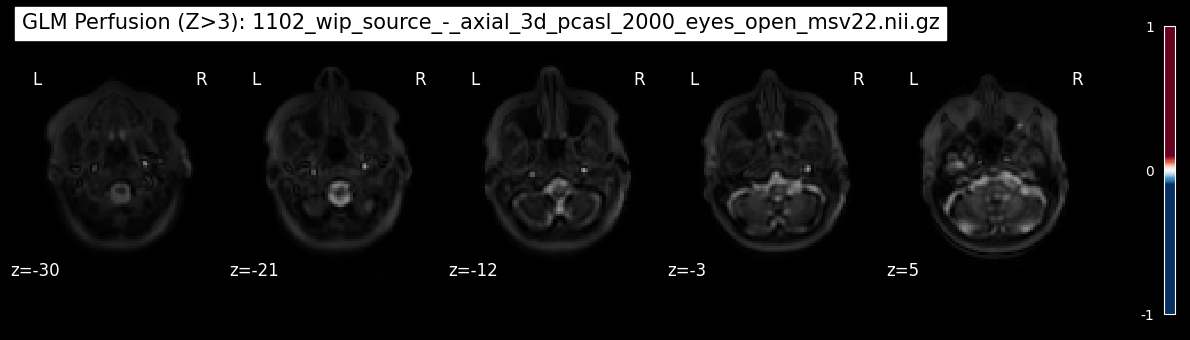

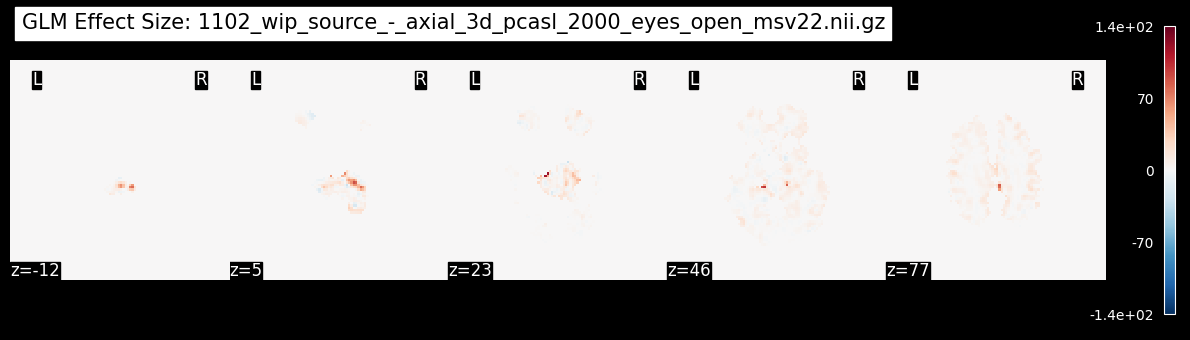

In [16]:

from nilearn.glm.first_level import FirstLevelModel
from nilearn import plotting, image
import pandas as pd


data_dir = Path("processed_data/fMRI")
output_dir = Path("processed_data/fMRI/glm_results")
output_dir.mkdir(parents=True, exist_ok=True)


pcasl_files = list(data_dir.glob("*pCASL*.nii.gz"))
pcasl_files = [f for f in pcasl_files if "PWI" not in f.name and "mean" not in f.name]


pcasl_path = pcasl_files[0]
print(f"Processing: {pcasl_path.name}")


img = nib.load(str(pcasl_path))
data = img.get_fdata()
n_scans = data.shape[3]
tr = img.header.get_zooms()[3]
print(f"Number of scans: {n_scans}, TR: {tr:.2f}s")

if n_scans % 2 != 0:
    data = data[..., :-1]
    img = nib.Nifti1Image(data, img.affine, img.header)
    n_scans -= 1

frame_times = np.arange(n_scans) * tr
conditions = np.tile([0.5, -0.5], n_scans // 2)

design_matrix = pd.DataFrame({
    'perfusion': conditions,
    'constant': np.ones(n_scans)
}, index=frame_times)

from nilearn.plotting import plot_design_matrix
plot_design_matrix(design_matrix)
plt.savefig(output_dir / "design_matrix.png")
plt.close()

fmri_glm = FirstLevelModel(t_r=tr,
                          noise_model='ar1',
                          standardize=False,
                          hrf_model=None,  
                          drift_model='cosine',
                          high_pass=0.01)

fmri_glm = fmri_glm.fit(img, design_matrices=design_matrix)

contrast_val = np.array([1, 0]) 
z_map = fmri_glm.compute_contrast(contrast_val, output_type='z_score')
eff_map = fmri_glm.compute_contrast(contrast_val, output_type='effect_size')

z_map.to_filename(output_dir / f"{pcasl_path.stem}_glm_z_map.nii.gz")
eff_map.to_filename(output_dir / f"{pcasl_path.stem}_glm_effect_map.nii.gz")

mean_img = image.mean_img(img)
plotting.plot_stat_map(z_map, bg_img=mean_img, threshold=3.0,
                      title=f"GLM Perfusion (Z>3): {pcasl_path.name}",
                      display_mode='z', cut_coords=5)
plt.savefig(output_dir / f"{pcasl_path.stem}_z_map.png")
plt.show()

plotting.plot_stat_map(eff_map, bg_img=mean_img, threshold='auto',
                      title=f"GLM Effect Size: {pcasl_path.name}",
                      display_mode='z', cut_coords=5)
plt.savefig(output_dir / f"{pcasl_path.stem}_effect_map.png")
plt.show()



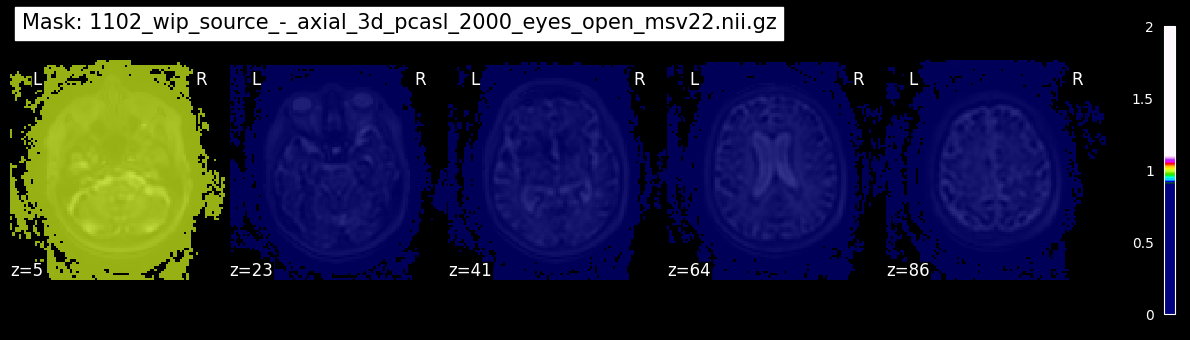

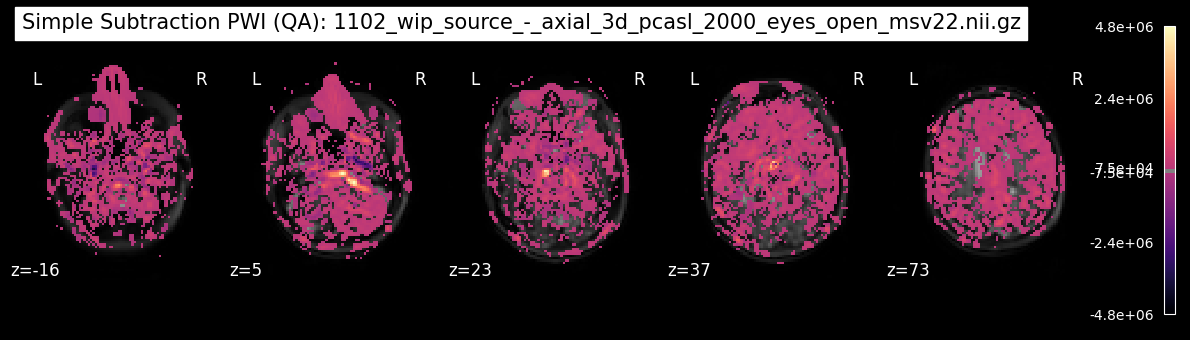

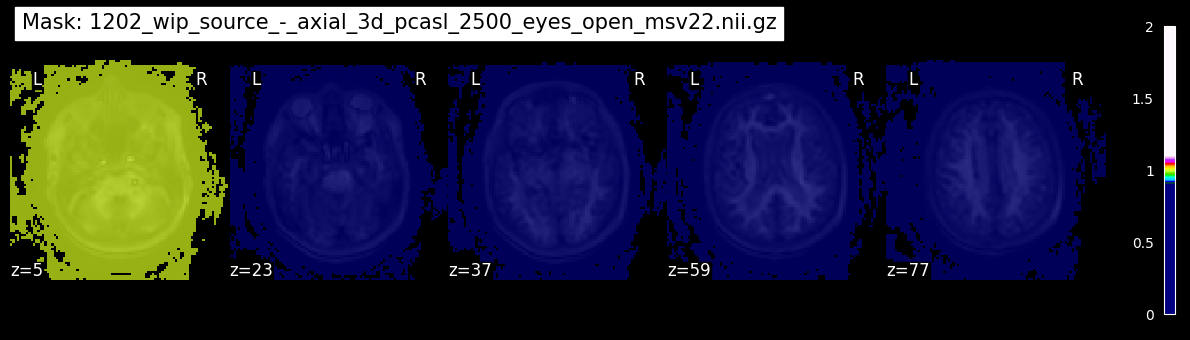

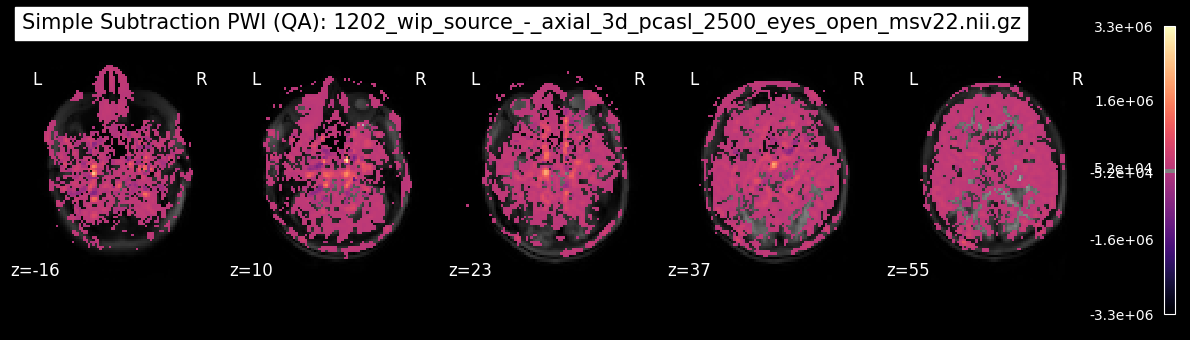

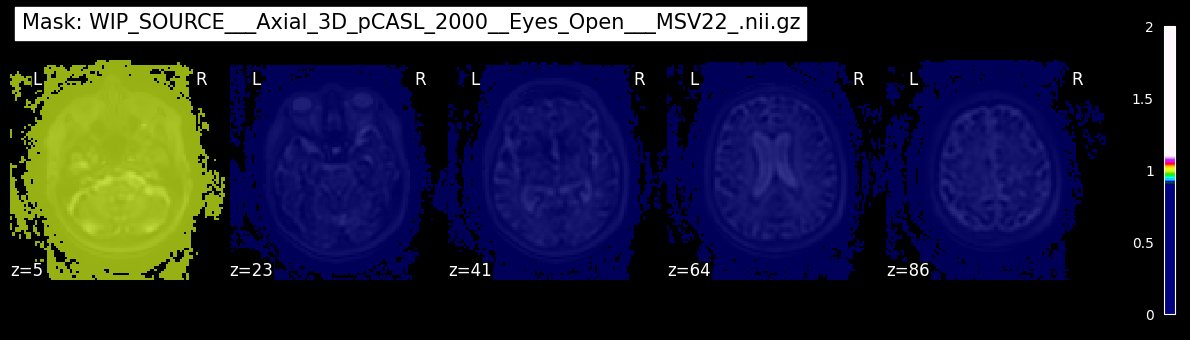

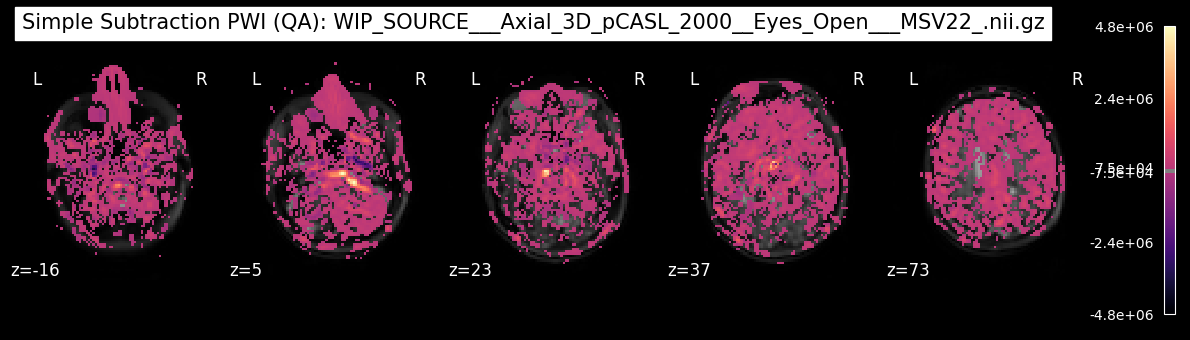

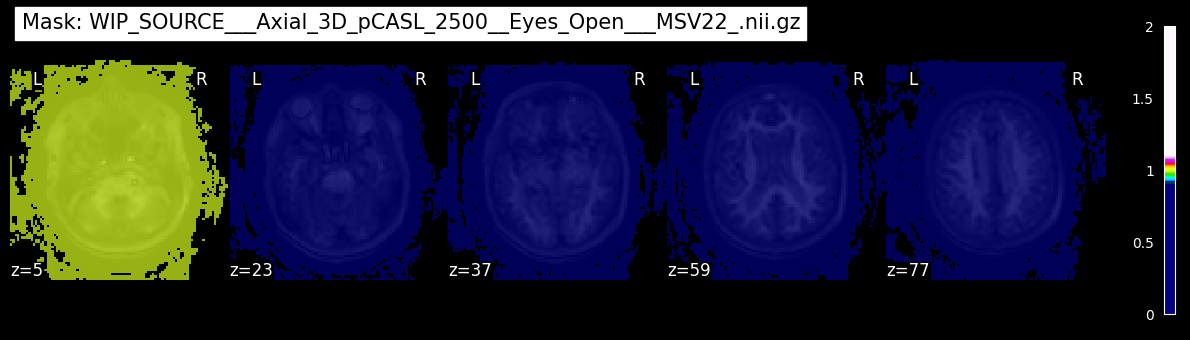

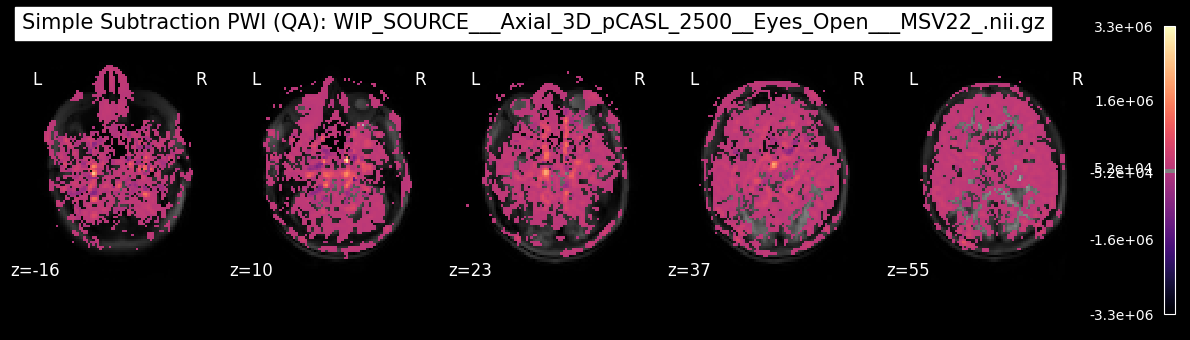

In [18]:
import numpy as np
import pandas as pd
import nibabel as nib
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt
from pathlib import Path
from nilearn import image, masking
from nilearn.glm.first_level import FirstLevelModel
from nilearn.plotting import plot_design_matrix, plot_stat_map, plot_roi

data_dir = Path("processed_data/fMRI")
output_dir = Path("processed_data/fMRI/glm_results")
output_dir.mkdir(parents=True, exist_ok=True)

pcasl_files = [f for f in data_dir.glob("*pCASL*.nii.gz") if "PWI" not in f.name and "mean" not in f.name]
if not pcasl_files:
    exit()

for pcasl_path in pcasl_files:
    img = nib.load(str(pcasl_path))
    data = img.get_fdata()
    n_scans = data.shape[3]
    tr = img.header.get_zooms()[3]

    if n_scans % 2 != 0:
        data = data[..., :-1]
        img = nib.Nifti1Image(data, img.affine, img.header)
        n_scans -= 1

    mean_img = image.mean_img(img)
    mask_img = masking.compute_epi_mask(mean_img, lower_cutoff=0.2, opening=False)

    if np.sum(mask_img.get_fdata()) == 0:
        mean_data = mean_img.get_fdata()
        threshold = np.percentile(mean_data[mean_data > 0], 10)
        mask_data = ndimage.binary_fill_holes(mean_data > threshold)
        mask_img = nib.Nifti1Image(mask_data.astype(np.int8), mean_img.affine)

    plot_roi(mask_img, bg_img=mean_img, title=f"Mask: {pcasl_path.name}", display_mode='z', cut_coords=5)
    plt.savefig(output_dir / f"{pcasl_path.stem}_mask_check.png")
    plt.show()

    ctrl = data[..., 0::2]
    lbl = data[..., 1::2]
    pwi_raw = np.mean(ctrl - lbl, axis=3)
    pwi_img_qa = nib.Nifti1Image(pwi_raw, img.affine, img.header)

    plot_stat_map(pwi_img_qa, bg_img=mean_img, threshold='auto',
                  title=f"Simple Subtraction PWI (QA): {pcasl_path.name}",
                  display_mode='z', cut_coords=5, cmap='magma')
    plt.savefig(output_dir / f"{pcasl_path.stem}_simple_subtraction_qa.png")
    plt.show()

    if n_scans < 6:
        continue

    frame_times = np.arange(n_scans) * tr
    conditions = np.tile([0.5, -0.5], n_scans // 2)

    design_matrix = pd.DataFrame({
        'perfusion': conditions,
        'constant': np.ones(n_scans)
    }, index=frame_times)

    plot_design_matrix(design_matrix)
    plt.savefig(output_dir / f"{pcasl_path.stem}_design_matrix.png")
    plt.close()

    fmri_glm = FirstLevelModel(t_r=tr,
                              mask_img=mask_img,
                              noise_model='ar1',
                              standardize=False,
                              hrf_model=None, 
                              drift_model='cosine',
                              high_pass=0.01)

    fmri_glm = fmri_glm.fit(img, design_matrices=design_matrix)

    contrast_val = np.array([1, 0])
    z_map = fmri_glm.compute_contrast(contrast_val, output_type='z_score')
    eff_map = fmri_glm.compute_contrast(contrast_val, output_type='effect_size')

    z_map.to_filename(output_dir / f"{pcasl_path.stem}_glm_z_map.nii.gz")
    eff_map.to_filename(output_dir / f"{pcasl_path.stem}_glm_effect_map.nii.gz")

    plot_stat_map(z_map, bg_img=mean_img, threshold=2.3,
                  title=f"GLM Perfusion (Z>2.3): {pcasl_path.name}",
                  display_mode='z', cut_coords=5, cmap='magma')
    plt.savefig(output_dir / f"{pcasl_path.stem}_z_map.png")
    plt.show()

    plot_stat_map(eff_map, bg_img=mean_img, threshold='auto',
                  title=f"GLM Effect Size: {pcasl_path.name}",
                  display_mode='z', cut_coords=5, cmap='magma')
    plt.savefig(output_dir / f"{pcasl_path.stem}_effect_map.png")
    plt.show()

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import dicom2nifti
import nilearn
from nilearn import plotting, image, decoding
from nilearn.masking import compute_epi_mask
from sklearn.model_selection import KFold

In [14]:
nifti_file = Path("C:/Users/user/Desktop/MRI_eval/processed_data/fMRI/Axial_MB_rsfMRI__EYES_OPEN___MSV22_.nii.gz")

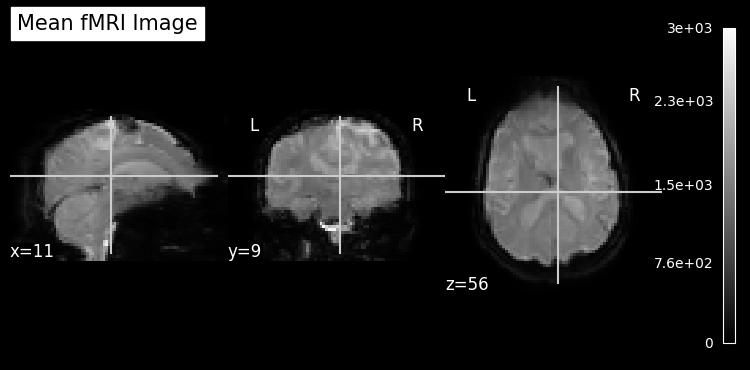

In [15]:
mean_img = image.mean_img(nifti_file)
plotting.plot_epi(mean_img, title="Mean fMRI Image")
plotting.show()

In [16]:
mask_img = compute_epi_mask(str(nifti_file))

fmri_img = image.load_img(str(nifti_file))
n_volumes = fmri_img.shape[3]
print(f"Number of volumes: {n_volumes}")


Number of volumes: 197


In [17]:
import random

conditions_list = []
block_size = 10
for i in range(n_volumes):
    if (i // block_size) % 2 == 0:
        conditions_list.append('Rest')
    else:
        conditions_list.append('Active')
        
behavioral = pd.DataFrame({'labels': conditions_list})
conditions = behavioral["labels"].to_numpy()

In [18]:

decoder = decoding.Decoder(
    estimator="svc",
    mask=mask_img,
    standardize=True,
    screening_percentile=5, 
    verbose=1
)

decoder.fit(str(nifti_file), conditions)

prediction = decoder.predict(str(nifti_file))
accuracy = (prediction == conditions).sum() / float(len(conditions))
print(f"Training Accuracy: {accuracy:.2f}")


[Decoder.fit] Loading mask from <nibabel.nifti1.Nifti1Image object at 0x00000222B07D3D90>

[Decoder.fit] Loading data from 
'C:\\Users\\user\\Desktop\\MRI_eval\\processed_data\\fMRI\\Axial_MB_rsfMRI__EYES_OPEN___MSV22_.nii.gz'

C:\Users\user\AppData\Local\Temp\ipykernel_1844\2781481770.py:9: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  decoder.fit(str(nifti_file), conditions)


[Decoder.fit] Resampling mask

[Decoder.fit] Finished fit

C:\Users\user\AppData\Local\Temp\ipykernel_1844\2781481770.py:9: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  decoder.fit(str(nifti_file), conditions)


[Decoder.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x00000222AF153B60>

[Decoder.fit] Extracting region signals

[Decoder.fit] Cleaning extracted signals

[Decoder.fit] Mask volume = 1.37186e+06mm^3 = 1371.86cm^3

[Decoder.fit] Standard brain volume = 1.88299e+06mm^3

[Decoder.fit] Original screening-percentile: 5

[Decoder.fit] Corrected screening-percentile: 6.86292

[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    4.0s finished


[Decoder.fit] Computing image from signals

[Decoder.fit] Computing image from signals

[Decoder.fit] Computing image from signals

[Decoder.fit] Computing image from signals

C:\Users\user\AppData\Local\Temp\ipykernel_1844\2781481770.py:11: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  prediction = decoder.predict(str(nifti_file))


[Decoder.predict] Loading data from <nibabel.nifti1.Nifti1Image object at 0x00000222AF153C80>

[Decoder.predict] Extracting region signals

[Decoder.predict] Cleaning extracted signals

Training Accuracy: 1.00


In [19]:
cv = KFold(n_splits=5)


fmri_data = image.load_img(str(nifti_file))

for fold, (train, test) in enumerate(cv.split(conditions), start=1):
    decoder.fit(image.index_img(fmri_data, train), conditions[train])
    prediction = decoder.predict(image.index_img(fmri_data, test))
    acc = (prediction == conditions[test]).sum() / float(len(conditions[test]))
    print(f"CV Fold {fold} | Accuracy: {acc:.3f}")

[Decoder.fit] Loading mask from <nibabel.nifti1.Nifti1Image object at 0x00000222B07D3D90>

[Decoder.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x00000222AF1B7020>

C:\Users\user\AppData\Local\Temp\ipykernel_1844\3059077520.py:7: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  decoder.fit(image.index_img(fmri_data, train), conditions[train])


[Decoder.fit] Resampling mask

[Decoder.fit] Finished fit

C:\Users\user\AppData\Local\Temp\ipykernel_1844\3059077520.py:7: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  decoder.fit(image.index_img(fmri_data, train), conditions[train])


[Decoder.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x00000222AF1B7020>

[Decoder.fit] Extracting region signals

[Decoder.fit] Cleaning extracted signals

[Decoder.fit] Mask volume = 1.37186e+06mm^3 = 1371.86cm^3

[Decoder.fit] Standard brain volume = 1.88299e+06mm^3

[Decoder.fit] Original screening-percentile: 5

[Decoder.fit] Corrected screening-percentile: 6.86292

[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    3.2s finished


[Decoder.fit] Computing image from signals

[Decoder.fit] Computing image from signals

[Decoder.fit] Computing image from signals

[Decoder.fit] Computing image from signals

C:\Users\user\AppData\Local\Temp\ipykernel_1844\3059077520.py:8: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  prediction = decoder.predict(image.index_img(fmri_data, test))


[Decoder.predict] Loading data from <nibabel.nifti1.Nifti1Image object at 0x00000222AF1B7E30>

[Decoder.predict] Extracting region signals

[Decoder.predict] Cleaning extracted signals

CV Fold 1 | Accuracy: 0.550


[Decoder.fit] Loading mask from <nibabel.nifti1.Nifti1Image object at 0x00000222B07D3D90>

[Decoder.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x00000222AF153B60>

C:\Users\user\AppData\Local\Temp\ipykernel_1844\3059077520.py:7: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  decoder.fit(image.index_img(fmri_data, train), conditions[train])


[Decoder.fit] Resampling mask

[Decoder.fit] Finished fit

C:\Users\user\AppData\Local\Temp\ipykernel_1844\3059077520.py:7: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  decoder.fit(image.index_img(fmri_data, train), conditions[train])


[Decoder.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x00000222AF153B60>

[Decoder.fit] Extracting region signals

[Decoder.fit] Cleaning extracted signals

[Decoder.fit] Mask volume = 1.37186e+06mm^3 = 1371.86cm^3

[Decoder.fit] Standard brain volume = 1.88299e+06mm^3

[Decoder.fit] Original screening-percentile: 5

[Decoder.fit] Corrected screening-percentile: 6.86292

[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    3.4s finished


[Decoder.fit] Computing image from signals

[Decoder.fit] Computing image from signals

[Decoder.fit] Computing image from signals

[Decoder.fit] Computing image from signals

C:\Users\user\AppData\Local\Temp\ipykernel_1844\3059077520.py:8: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  prediction = decoder.predict(image.index_img(fmri_data, test))


[Decoder.predict] Loading data from <nibabel.nifti1.Nifti1Image object at 0x00000222AF1B7020>

[Decoder.predict] Extracting region signals

[Decoder.predict] Cleaning extracted signals

CV Fold 2 | Accuracy: 0.575


[Decoder.fit] Loading mask from <nibabel.nifti1.Nifti1Image object at 0x00000222B07D3D90>

[Decoder.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x00000222AF153530>

C:\Users\user\AppData\Local\Temp\ipykernel_1844\3059077520.py:7: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  decoder.fit(image.index_img(fmri_data, train), conditions[train])


[Decoder.fit] Resampling mask

[Decoder.fit] Finished fit

C:\Users\user\AppData\Local\Temp\ipykernel_1844\3059077520.py:7: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  decoder.fit(image.index_img(fmri_data, train), conditions[train])


[Decoder.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x00000222AF153530>

[Decoder.fit] Extracting region signals

[Decoder.fit] Cleaning extracted signals

[Decoder.fit] Mask volume = 1.37186e+06mm^3 = 1371.86cm^3

[Decoder.fit] Standard brain volume = 1.88299e+06mm^3

[Decoder.fit] Original screening-percentile: 5

[Decoder.fit] Corrected screening-percentile: 6.86292

[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    3.6s finished


[Decoder.fit] Computing image from signals

[Decoder.fit] Computing image from signals

[Decoder.fit] Computing image from signals

[Decoder.fit] Computing image from signals

C:\Users\user\AppData\Local\Temp\ipykernel_1844\3059077520.py:8: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  prediction = decoder.predict(image.index_img(fmri_data, test))


[Decoder.predict] Loading data from <nibabel.nifti1.Nifti1Image object at 0x00000222AF1B7E30>

[Decoder.predict] Extracting region signals

[Decoder.predict] Cleaning extracted signals

CV Fold 3 | Accuracy: 0.436


[Decoder.fit] Loading mask from <nibabel.nifti1.Nifti1Image object at 0x00000222B07D3D90>

[Decoder.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x00000222AF153AD0>

C:\Users\user\AppData\Local\Temp\ipykernel_1844\3059077520.py:7: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  decoder.fit(image.index_img(fmri_data, train), conditions[train])


[Decoder.fit] Resampling mask

[Decoder.fit] Finished fit

C:\Users\user\AppData\Local\Temp\ipykernel_1844\3059077520.py:7: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  decoder.fit(image.index_img(fmri_data, train), conditions[train])


[Decoder.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x00000222AF153AD0>

[Decoder.fit] Extracting region signals

[Decoder.fit] Cleaning extracted signals

[Decoder.fit] Mask volume = 1.37186e+06mm^3 = 1371.86cm^3

[Decoder.fit] Standard brain volume = 1.88299e+06mm^3

[Decoder.fit] Original screening-percentile: 5

[Decoder.fit] Corrected screening-percentile: 6.86292

[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    3.6s finished


[Decoder.fit] Computing image from signals

[Decoder.fit] Computing image from signals

[Decoder.fit] Computing image from signals

[Decoder.fit] Computing image from signals

C:\Users\user\AppData\Local\Temp\ipykernel_1844\3059077520.py:8: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  prediction = decoder.predict(image.index_img(fmri_data, test))


[Decoder.predict] Loading data from <nibabel.nifti1.Nifti1Image object at 0x00000222AF1B7020>

[Decoder.predict] Extracting region signals

[Decoder.predict] Cleaning extracted signals

CV Fold 4 | Accuracy: 0.308


[Decoder.fit] Loading mask from <nibabel.nifti1.Nifti1Image object at 0x00000222B07D3D90>

[Decoder.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x00000222AF150F80>

C:\Users\user\AppData\Local\Temp\ipykernel_1844\3059077520.py:7: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  decoder.fit(image.index_img(fmri_data, train), conditions[train])


[Decoder.fit] Resampling mask

[Decoder.fit] Finished fit

C:\Users\user\AppData\Local\Temp\ipykernel_1844\3059077520.py:7: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  decoder.fit(image.index_img(fmri_data, train), conditions[train])


[Decoder.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x00000222AF150F80>

[Decoder.fit] Extracting region signals

[Decoder.fit] Cleaning extracted signals

[Decoder.fit] Mask volume = 1.37186e+06mm^3 = 1371.86cm^3

[Decoder.fit] Standard brain volume = 1.88299e+06mm^3

[Decoder.fit] Original screening-percentile: 5

[Decoder.fit] Corrected screening-percentile: 6.86292

[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    4.6s finished


[Decoder.fit] Computing image from signals

[Decoder.fit] Computing image from signals

[Decoder.fit] Computing image from signals

[Decoder.fit] Computing image from signals

C:\Users\user\AppData\Local\Temp\ipykernel_1844\3059077520.py:8: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  prediction = decoder.predict(image.index_img(fmri_data, test))


[Decoder.predict] Loading data from <nibabel.nifti1.Nifti1Image object at 0x00000222AF1536E0>

[Decoder.predict] Extracting region signals

[Decoder.predict] Cleaning extracted signals

CV Fold 5 | Accuracy: 0.487


c:\Users\user\Desktop\MRI_eval\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



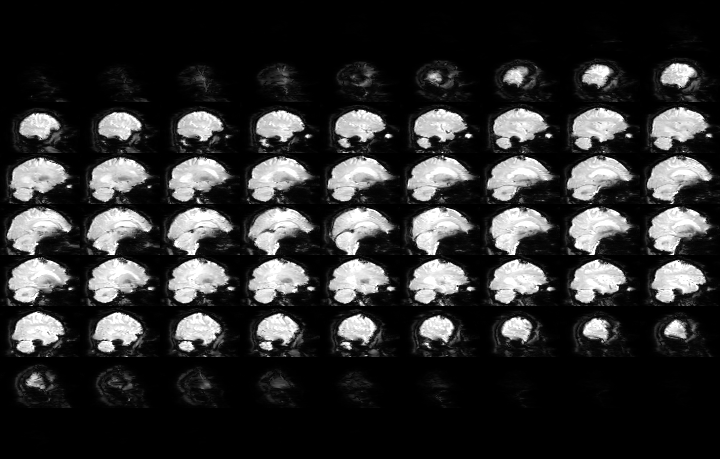
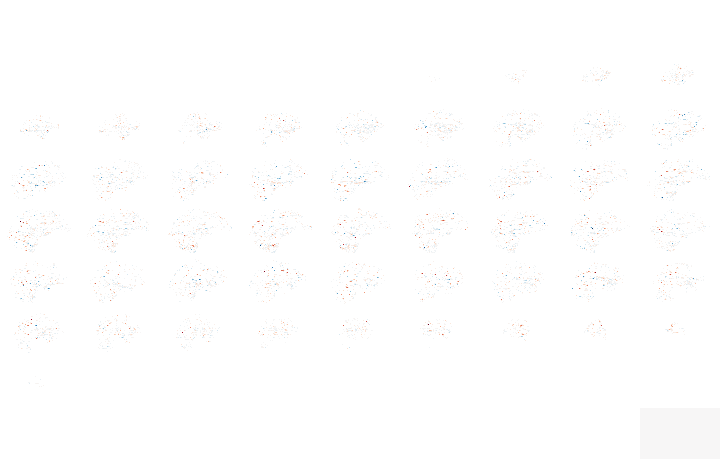

In [39]:
target_class = 'Active' if 'Active' in decoder.classes_ else decoder.classes_[0]
coef_img = decoder.coef_img_[target_class]
plotting.view_img(
    coef_img,
    bg_img=mean_img,
    title=f"Active Voxels",
    threshold='50%',
    dim=-1
)


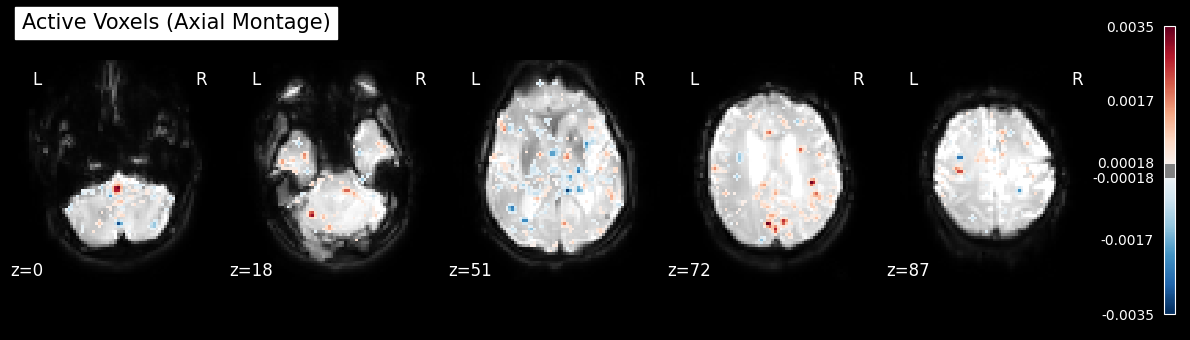

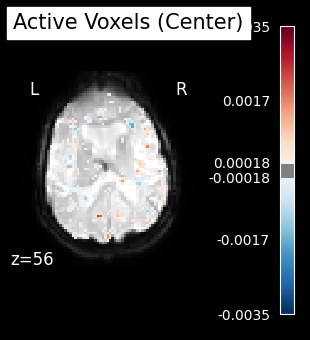

In [38]:
from nilearn.plotting import plot_stat_map, find_xyz_cut_coords
from nilearn.image import smooth_img, get_data

smooth_weights = smooth_img(coef_img, fwhm=4)

data = get_data(smooth_weights)
threshold = np.percentile(np.abs(data[data != 0]), 90)

plot_stat_map(
    smooth_weights,
    bg_img=mean_img,
    title="Active Voxels (Axial Montage)",
    threshold=threshold,
    display_mode='z',
    cut_coords=5, 
    dim=-1
)
plotting.show()

anatomy_center = find_xyz_cut_coords(mean_img)

plot_stat_map(
    smooth_weights,
    bg_img=mean_img,
    title="Active Voxels (Center)",
    threshold=threshold,
    display_mode='z',
    cut_coords=[anatomy_center[2]], 
    dim=-1
)

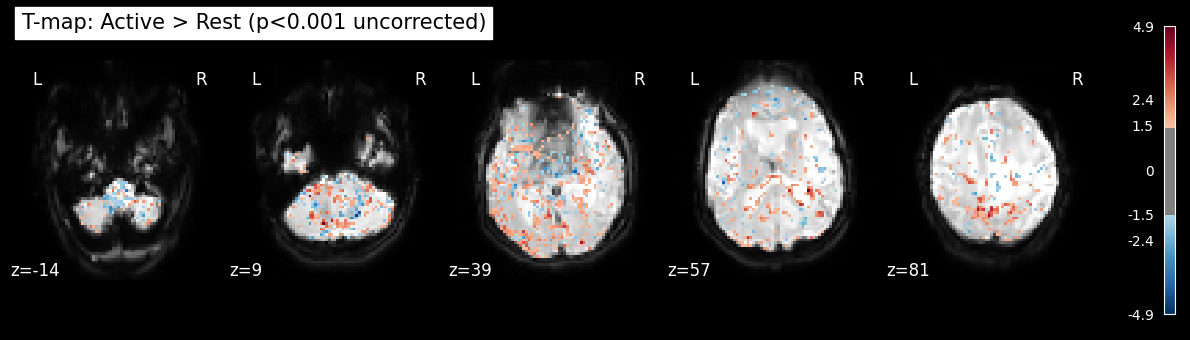

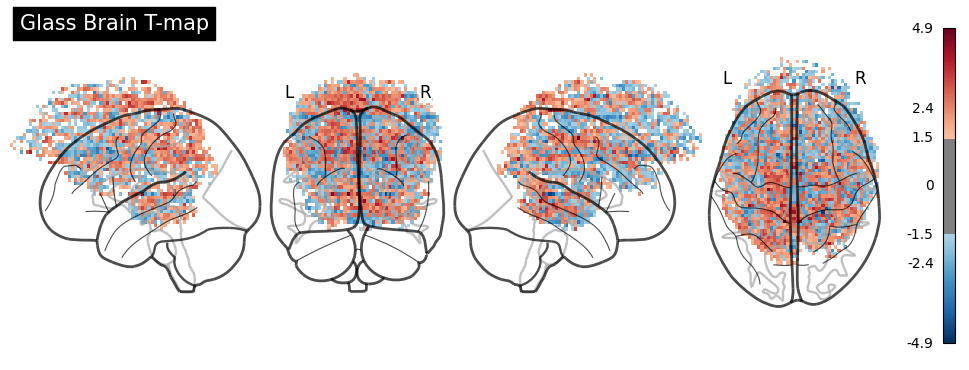

In [42]:
from nilearn.glm.first_level import FirstLevelModel
from nilearn.plotting import plot_stat_map, plot_glass_brain
from nilearn.image import smooth_img
import pandas as pd

tr = 2.0  
n_scans = len(conditions)
frame_times = np.arange(n_scans) * tr

events = pd.DataFrame({
    'onset': frame_times,
    'duration': [tr] * n_scans,
    'trial_type': conditions 
})


fmri_glm = FirstLevelModel(
    t_r=tr,
    noise_model='ar1',
    standardize=True,
    hrf_model='spm',
    drift_model='cosine',
    high_pass=0.01
)


fmri_glm = fmri_glm.fit(nifti_file, events)

design_matrix = fmri_glm.design_matrices_[0]
contrast_matrix = np.eye(design_matrix.shape[1])
active_col = design_matrix.columns.get_loc('Active')
rest_col = design_matrix.columns.get_loc('Rest')


contrast_val = np.zeros(design_matrix.shape[1])
contrast_val[active_col] = 1
contrast_val[rest_col] = -1


t_map = fmri_glm.compute_contrast(contrast_val, stat_type='t', output_type='stat')

plot_stat_map(
    t_map, 
    bg_img=mean_img, 
    threshold=1.5, 
    title="T-map: Active > Rest (p<0.001 uncorrected)",
    display_mode='z', 
    cut_coords=5,
    dim=-1
)
plotting.show()


plot_glass_brain(
    t_map, 
    title='Glass Brain T-map', 
    threshold=1.5, 
    display_mode='lyrz', 
    plot_abs=False
)
plotting.show()

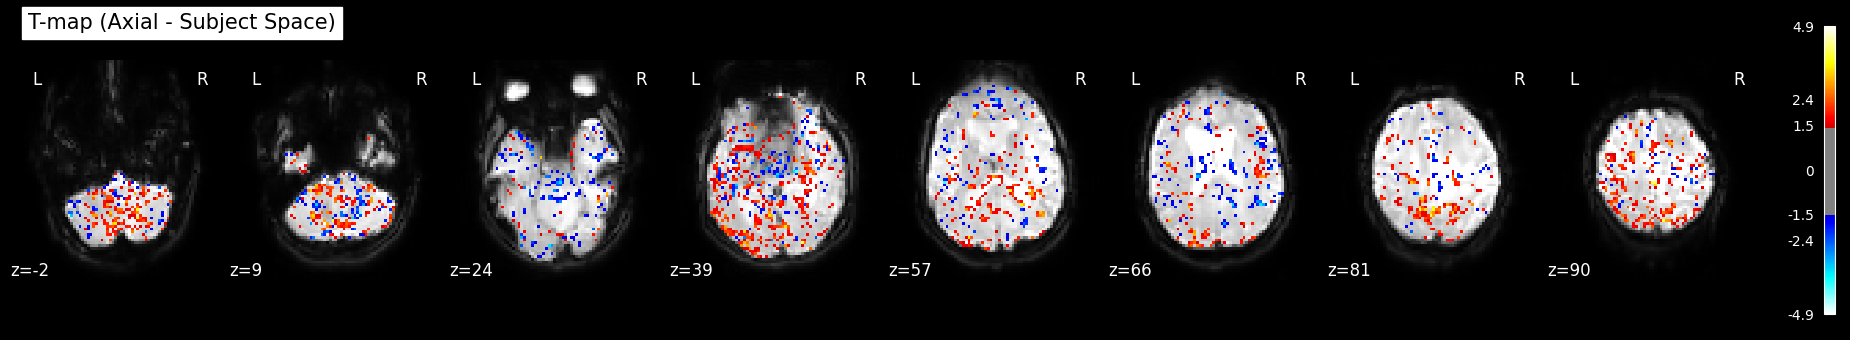

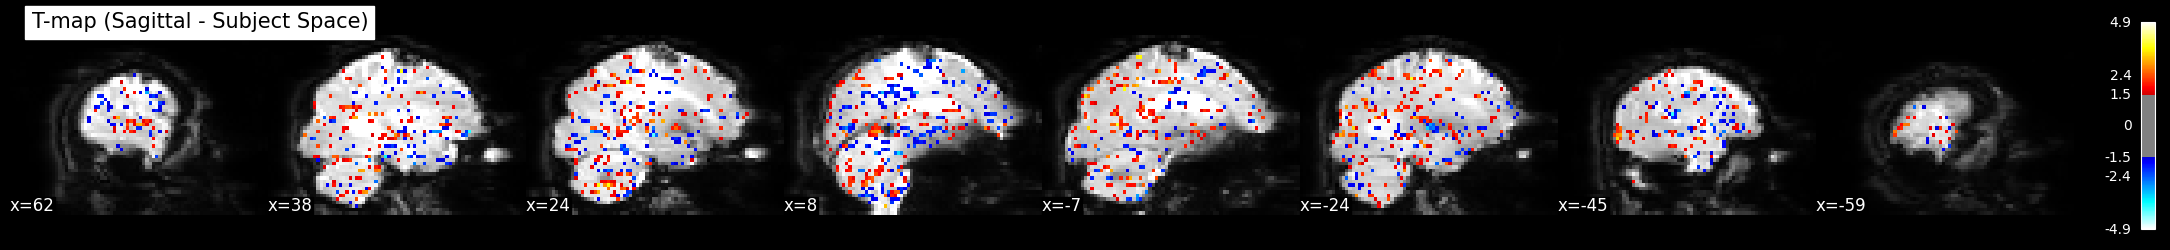

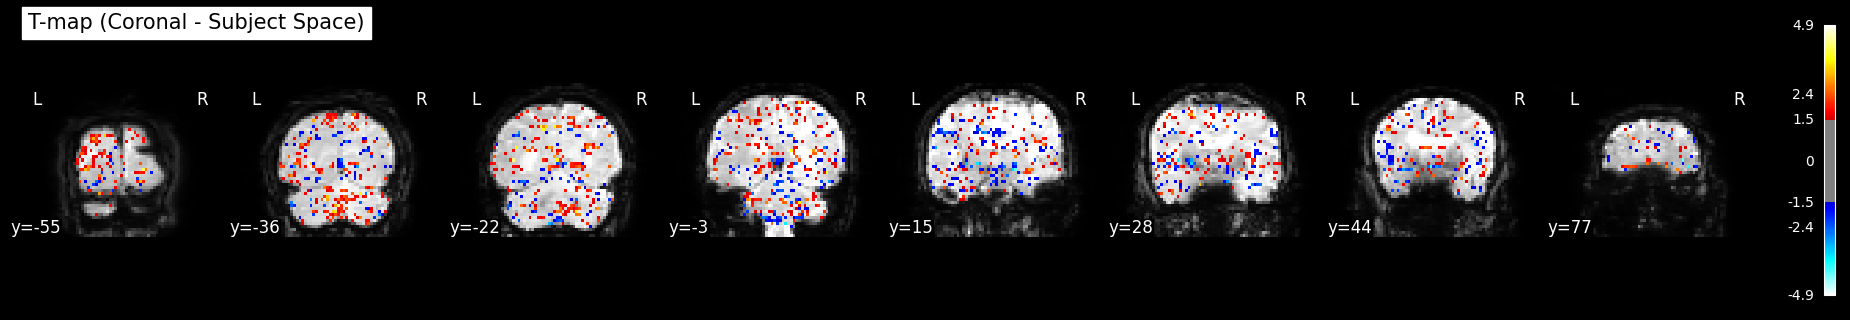

In [46]:
from nilearn.plotting import plot_stat_map


plot_stat_map(
    t_map, 
    bg_img=mean_img, 
    title="T-map (Axial - Subject Space)", 
    display_mode='z', 
    cut_coords=8,    
    threshold=1.5,   
    dim=-1,
    cmap='cold_hot'  
)
plotting.show()

plot_stat_map(
    t_map, 
    bg_img=mean_img, 
    title="T-map (Sagittal - Subject Space)", 
    display_mode='x', 
    cut_coords=8, 
    threshold=1.5,
    dim=-1,
    cmap='cold_hot'
)
plotting.show()

plot_stat_map(
    t_map, 
    bg_img=mean_img, 
    title="T-map (Coronal - Subject Space)", 
    display_mode='y', 
    cut_coords=8, 
    threshold=1.5,
    dim=-1,
    cmap='cold_hot'
)
plotting.show()

In [43]:
from nilearn.datasets import (
    load_mni152_template,
    load_sample_motor_activation_image,
)

template = load_mni152_template(resolution=2)

stat_img = load_sample_motor_activation_image()

In [44]:
from nilearn.image import resample_to_img

resampled_stat_img = resample_to_img(stat_img, template)


from nilearn.image import load_img

tmap_img = load_img(stat_img)

original_shape = tmap_img.shape
original_affine = tmap_img.affine

resampled_shape = resampled_stat_img.shape
resampled_affine = resampled_stat_img.affine

template_img = load_img(template)
template_shape = template_img.shape
template_affine = template_img.affine
print(
    f"""Shape comparison:
- Original t-map image shape : {original_shape}
- Resampled t-map image shape: {resampled_shape}
- Template image shape       : {template_shape}
"""
)

print(
    f"""Affine comparison:
- Original t-map image affine :
 {original_affine}
- Resampled t-map image affine:
 {resampled_affine}
- Template image affine       :
 {template_affine}
"""
)

Shape comparison:
- Original t-map image shape : (53, 63, 46)
- Resampled t-map image shape: (99, 117, 95)
- Template image shape       : (99, 117, 95)

Affine comparison:
- Original t-map image affine :
 [[  -3.    0.    0.   78.]
 [   0.    3.    0. -112.]
 [   0.    0.    3.  -50.]
 [   0.    0.    0.    1.]]
- Resampled t-map image affine:
 [[   2.    0.    0.  -98.]
 [   0.    2.    0. -134.]
 [   0.    0.    2.  -72.]
 [   0.    0.    0.    1.]]
- Template image affine       :
 [[   2.    0.    0.  -98.]
 [   0.    2.    0. -134.]
 [   0.    0.    2.  -72.]
 [   0.    0.    0.    1.]]



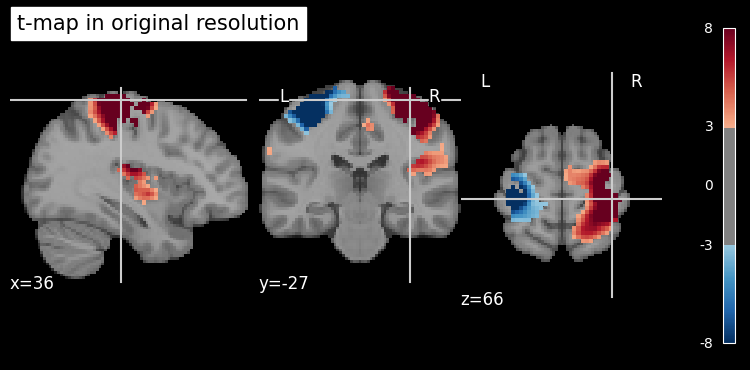

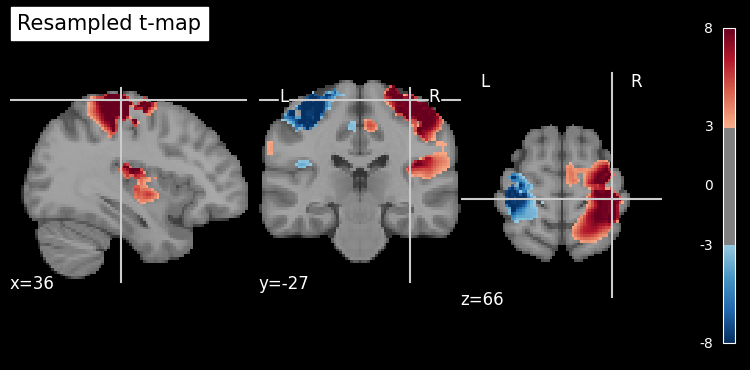

In [45]:
from nilearn import plotting

plotting.plot_stat_map(
    stat_img,
    bg_img=template,
    cut_coords=(36, -27, 66),
    threshold=3,
    title="t-map in original resolution",
    vmax=8,
)
plotting.plot_stat_map(
    resampled_stat_img,
    bg_img=template,
    cut_coords=(36, -27, 66),
    threshold=3,
    title="Resampled t-map",
    vmax=8,
)
plotting.show()